In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [4]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [5]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


Since we have 819 missing values in addiction_level check for percentage.

If the percentage is less dhan  10% we can drop the rows containing missing values.

In [8]:
df["addiction_level"].isnull().mean() * 100

np.float64(10.92)

In [10]:
#Drop the rows containing missing values
df = df.dropna(subset=["addiction_level"])

In [12]:
#Check for missing values
df["addiction_level"].isnull().sum()

np.int64(0)

In [13]:
print("Remaining rows:", df.shape[0])

Remaining rows: 6681


In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')
Categorical Columns: Index(['transaction_id', 'user_id', 'gender', 'stress_level',
       'academic_work_impact', 'addiction_level'],
      dtype='object')


In [15]:
df[num_cols].describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000
mean,26.580602,7.864862,3.400090,2.015176,3.240322,6.744914,134.244275,97.921269,9.613552,0.794492
std,5.201722,2.516355,1.594324,1.146717,1.599141,1.285371,66.502620,48.353895,2.623642,0.404103
min,18.000000,3.010000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.630000,0.000000
25%,22.000000,5.920000,2.030000,1.010000,1.840000,5.640000,76.000000,56.000000,7.570000,1.000000
50%,27.000000,8.010000,3.510000,2.050000,3.220000,6.730000,134.000000,98.000000,9.750000,1.000000
75%,31.000000,10.050000,4.790000,2.990000,4.640000,7.860000,191.000000,140.000000,11.750000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


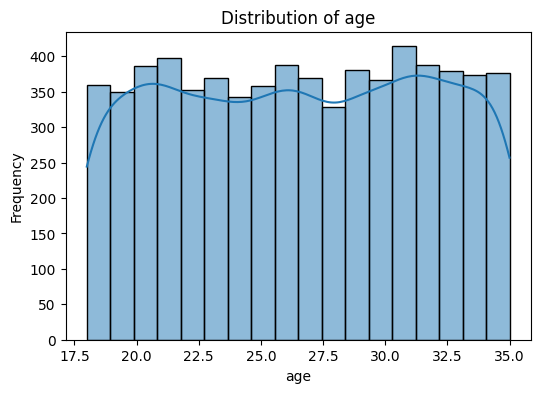

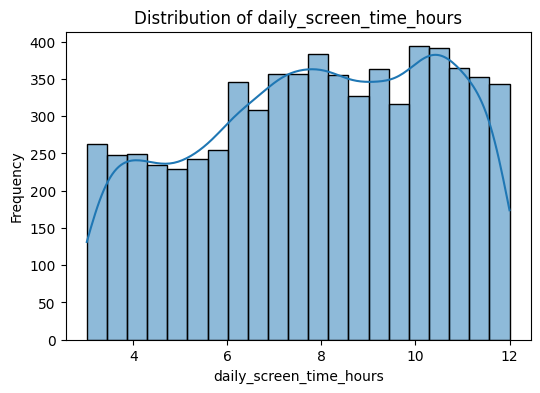

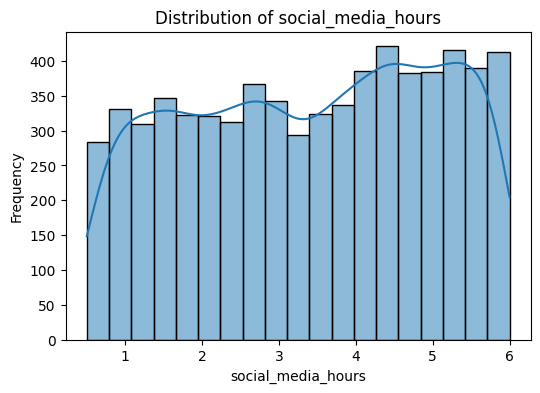

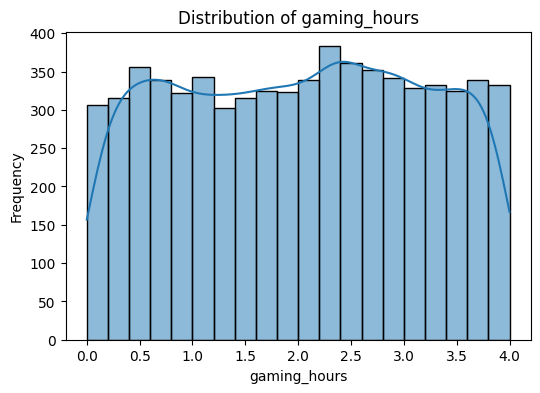

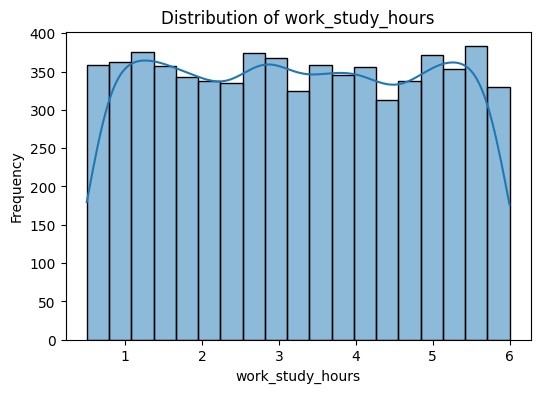

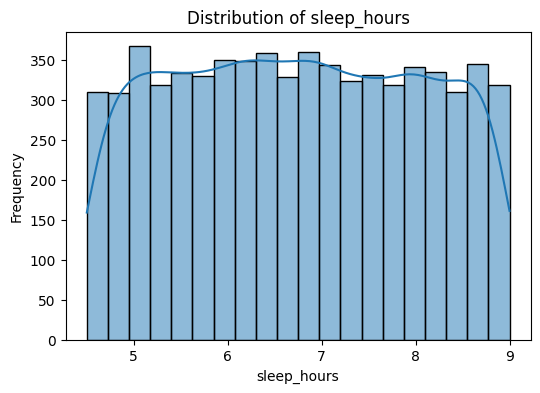

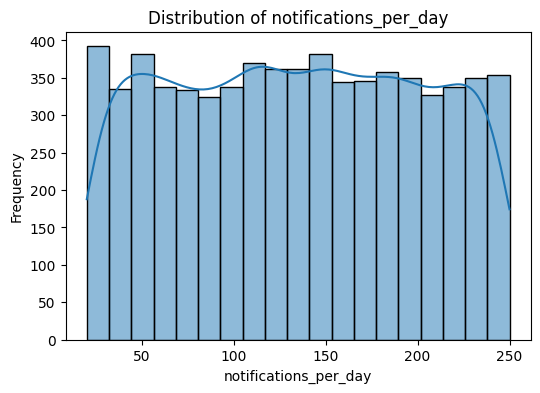

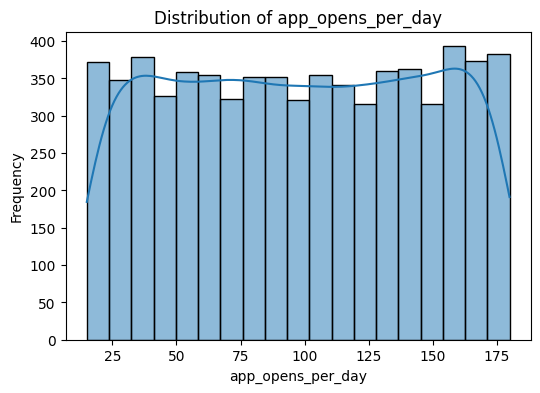

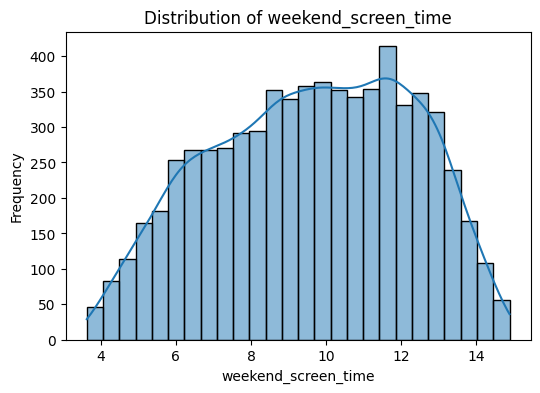

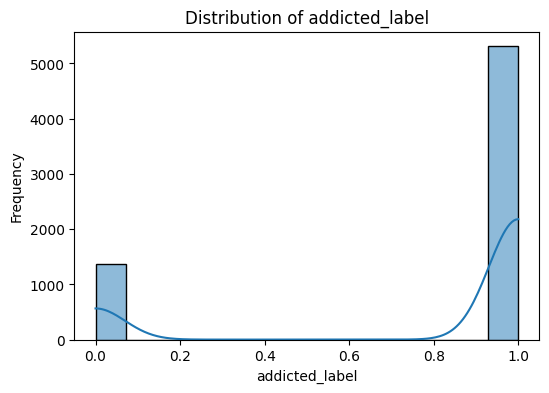

In [17]:
#Distribution plots
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

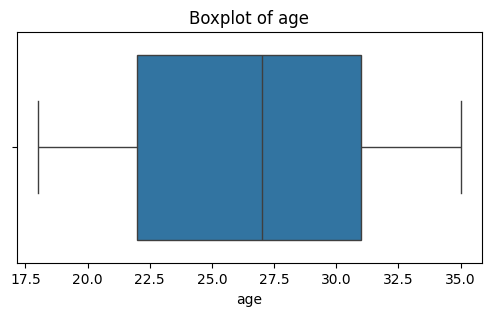

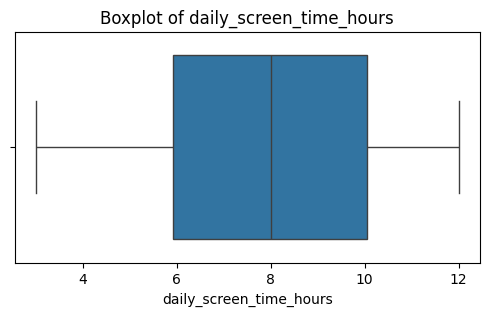

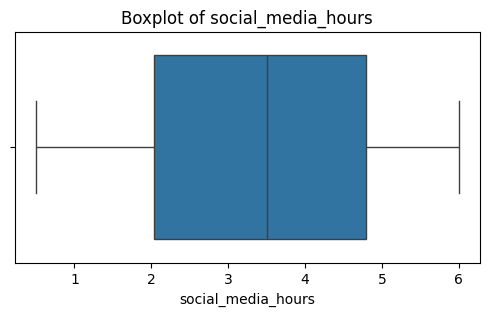

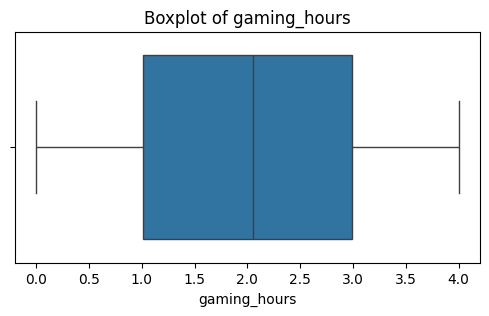

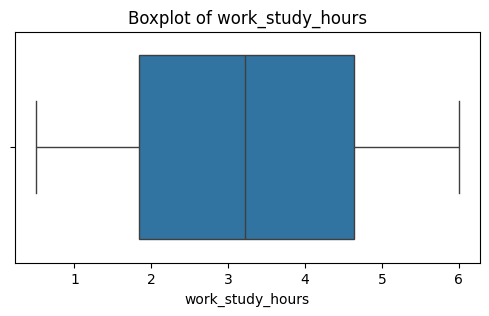

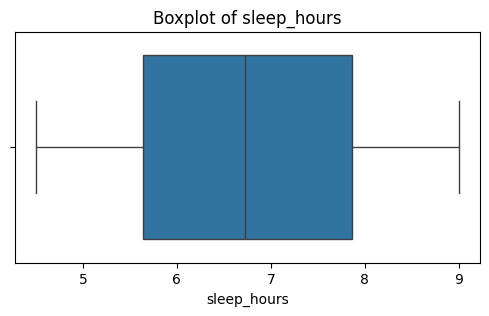

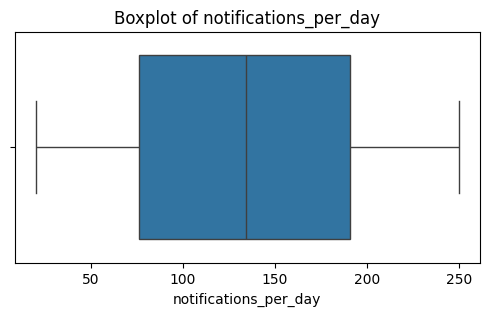

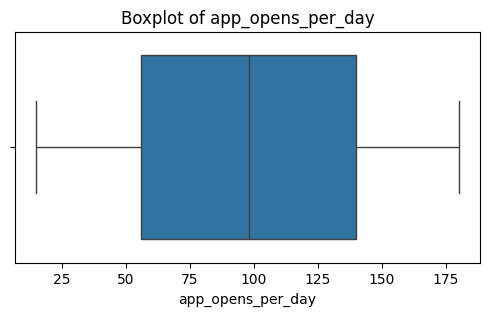

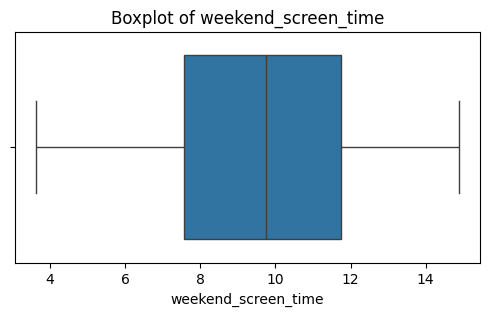

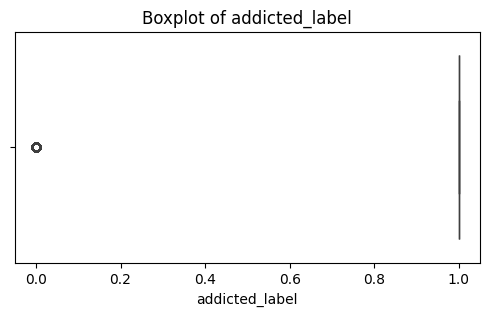

In [18]:
#Boxplot to detect outliers in each column
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## **Univariate Analysis for Categorical Variables**

### Frequency Count

In [19]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for transaction_id:
transaction_id
TXN07500    1
TXN00003    1
TXN00004    1
TXN00005    1
TXN00006    1
           ..
TXN00021    1
TXN00020    1
TXN00019    1
TXN00018    1
TXN00015    1
Name: count, Length: 6681, dtype: int64

Value counts for user_id:
user_id
U07500    1
U00003    1
U00004    1
U00005    1
U00006    1
         ..
U00021    1
U00020    1
U00019    1
U00018    1
U00015    1
Name: count, Length: 6681, dtype: int64

Value counts for gender:
gender
Male      2284
Other     2214
Female    2183
Name: count, dtype: int64

Value counts for stress_level:
stress_level
High      2271
Low       2254
Medium    2156
Name: count, dtype: int64

Value counts for academic_work_impact:
academic_work_impact
No     3346
Yes    3335
Name: count, dtype: int64

Value counts for addiction_level:
addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64


### Count plot

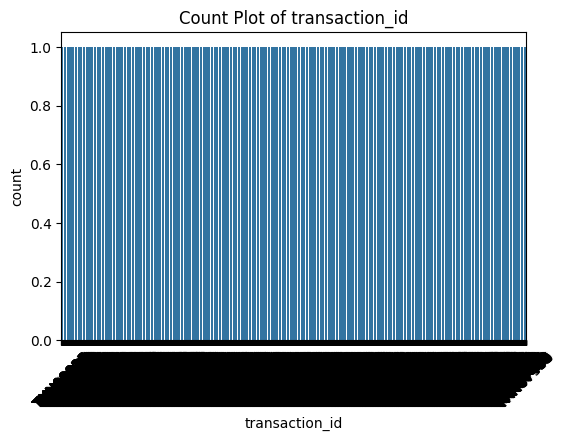

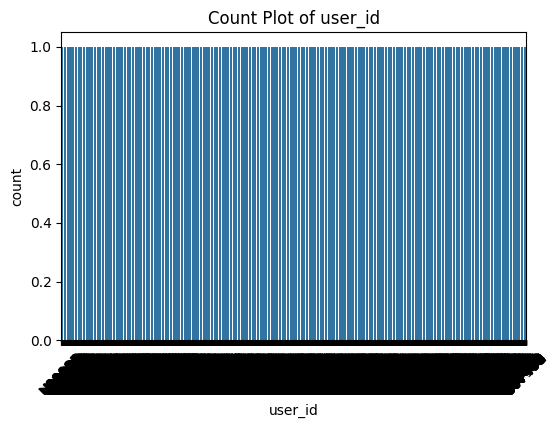

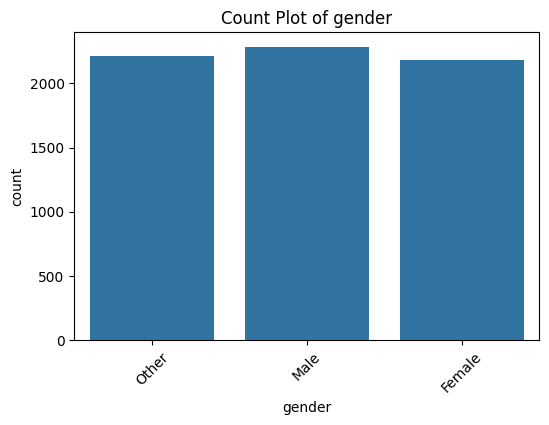

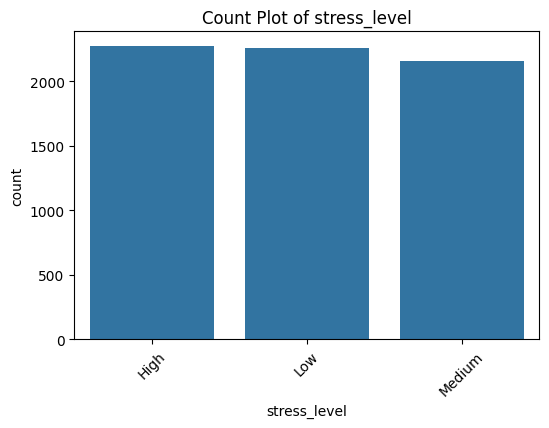

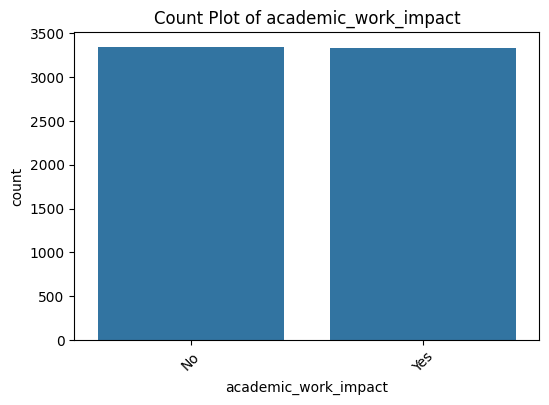

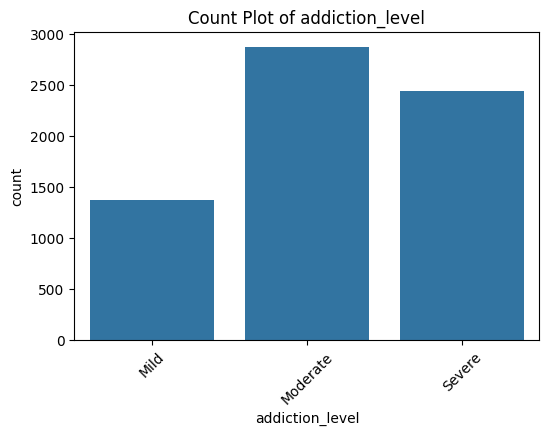

In [20]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

## Screen time

In [24]:
df[num_cols].skew()

,0
age,-0.021560
daily_screen_time_hours,-0.198545
social_media_hours,-0.115667
gaming_hours,-0.023457
work_study_hours,0.009987
sleep_hours,0.012694
notifications_per_day,0.003186
app_opens_per_day,-0.006692
weekend_screen_time,-0.170854
addicted_label,-1.457946


Interpretation:

0 → Right skew

< 0 → Left skew

# Bivariate Analysis

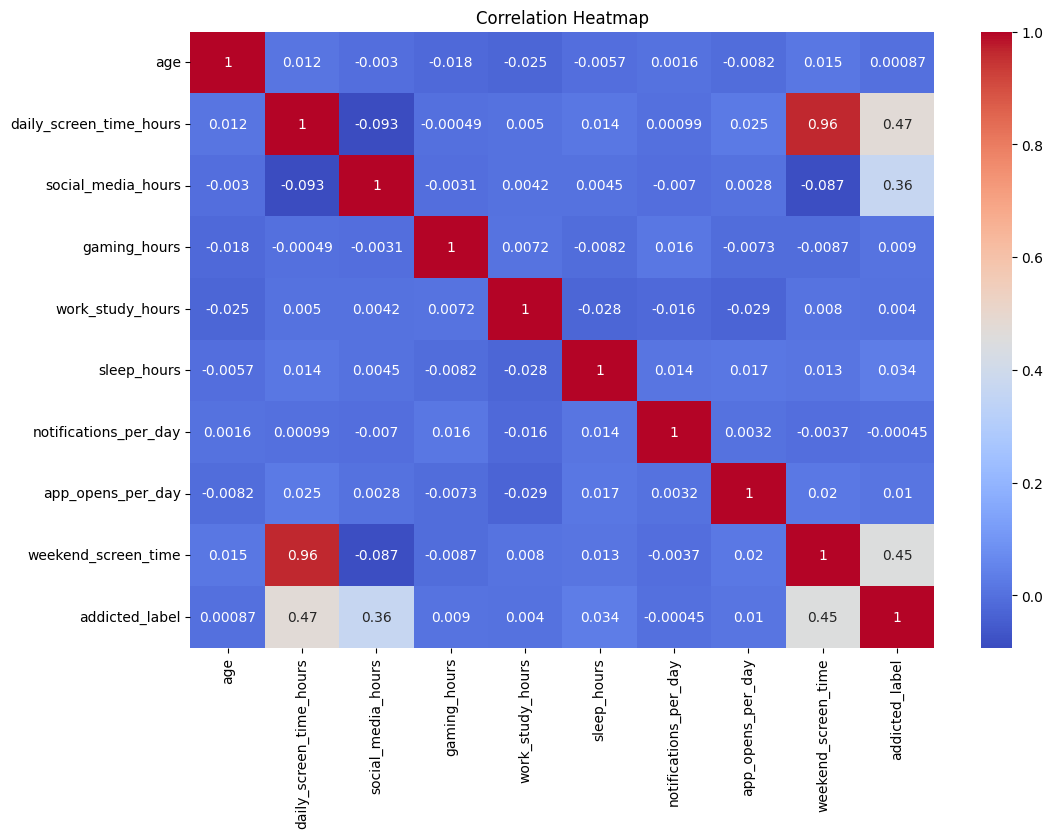

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

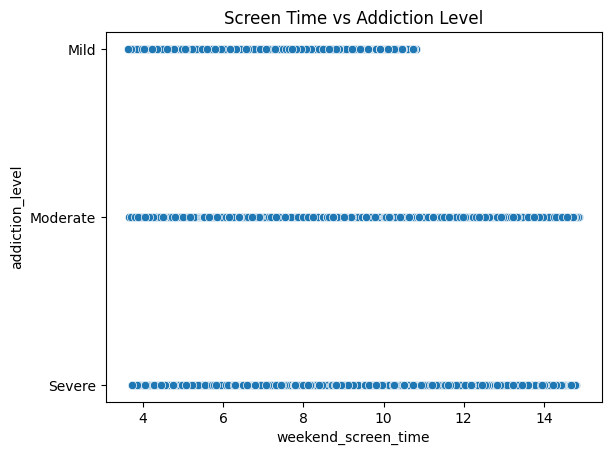

In [28]:
#Screen time vs. Addiction level
sns.scatterplot(x="weekend_screen_time", y="addiction_level", data=df)
plt.title("Screen Time vs Addiction Level")
plt.show()

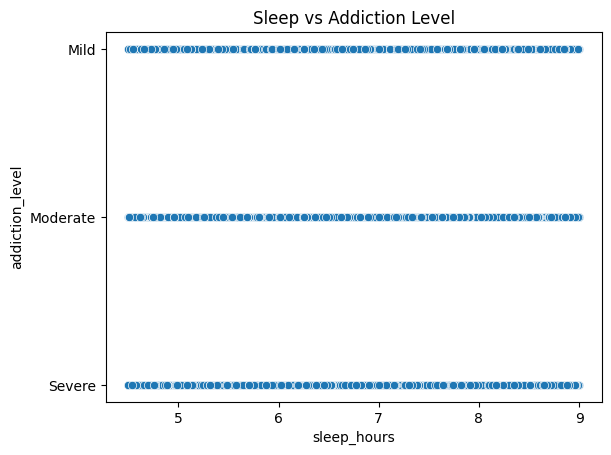

In [30]:
#Sleep vs addiction
sns.scatterplot(x="sleep_hours", y="addiction_level", data=df)
plt.title("Sleep vs Addiction Level")
plt.show()

More screen time → higher addiction

Less sleep → higher addiction

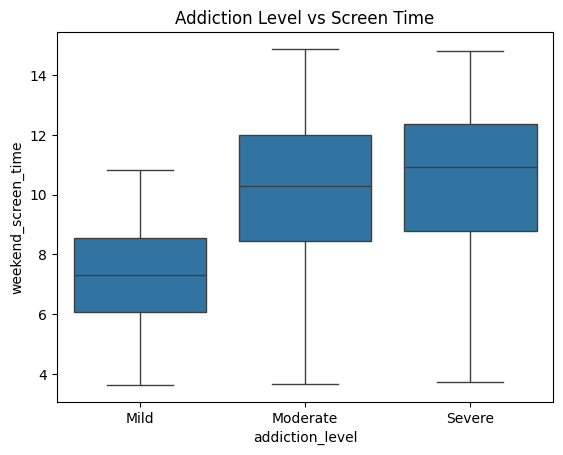

In [31]:
#Categorical vs numerical
#Addiction Level vs Screen Time
sns.boxplot(x="addiction_level", y="weekend_screen_time", data=df)
plt.title("Addiction Level vs Screen Time")
plt.show()

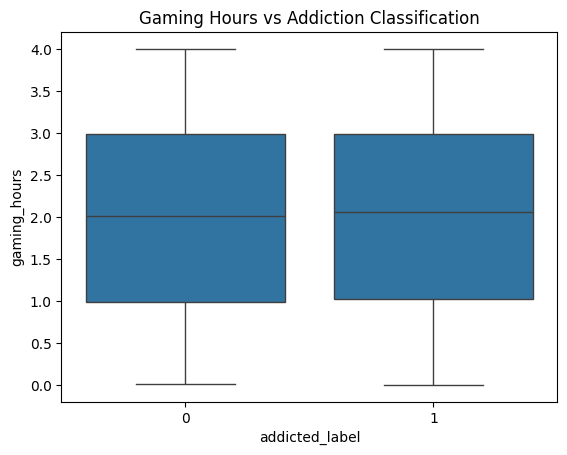

In [33]:
#Addiction Classification vs Gaming Hours
sns.boxplot(x="addicted_label", y="gaming_hours", data=df)
plt.title("Gaming Hours vs Addiction Classification")
plt.show()

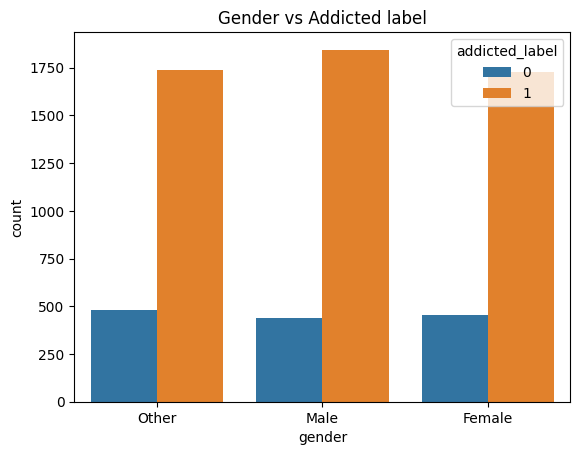

In [35]:
#Categorical vs categorical
#Gender vs Addicted label
sns.countplot(x="gender", hue="addicted_label", data=df)
plt.title("Gender vs Addicted label")
plt.show()

# Multi-variable Interaction

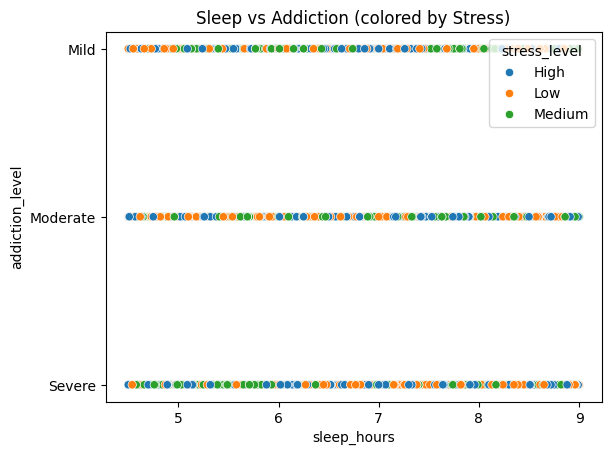

In [36]:
sns.scatterplot(
    x="sleep_hours",
    y="addiction_level",
    hue="stress_level",
    data=df
)
plt.title("Sleep vs Addiction (colored by Stress)")
plt.show()

In [38]:
addiction_level_mapping = {'Mild': 1, 'Moderate': 2, 'Severe': 3}
df['addiction_level_encoded'] = df['addiction_level'].map(addiction_level_mapping)
df.corr(numeric_only=True)["addiction_level_encoded"].sort_values(ascending=False)

,addiction_level_encoded
addiction_level_encoded,1.000000
addicted_label,0.798621
daily_screen_time_hours,0.402979
weekend_screen_time,0.386800
social_media_hours,0.333285
sleep_hours,0.031332
age,0.017469
app_opens_per_day,0.010926
work_study_hours,0.004311
gaming_hours,0.000739
